In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('smmh.csv')

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
df.head()

Shape: (481, 21)

Columns:
 ['Timestamp', '1. What is your age?', '2. Gender', '3. Relationship Status', '4. Occupation Status', '5. What type of organizations are you affiliated with?', '6. Do you use social media?', '7. What social media platforms do you commonly use?', '8. What is the average time you spend on social media every day?', '9. How often do you find yourself using Social media without a specific purpose?', '10. How often do you get distracted by Social media when you are busy doing something?', "11. Do you feel restless if you haven't used Social media in a while?", '12. On a scale of 1 to 5, how easily distracted are you?', '13. On a scale of 1 to 5, how much are you bothered by worries?', '14. Do you find it difficult to concentrate on things?', '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?', '16. Following the previous question, how do you feel about these comparisons, generally speaking?', '17. H

,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,...,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,...,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,...,4,4,5,5,3,3,3,4,4,1


In [ ]:
# Clean column names (remove extra spaces)
df.columns = [col.strip() for col in df.columns]

# Target Variable (Single question - Simple & Clear)
target = '18. How often do you feel depressed or down?'
y = df[target].astype(float)

# Optional: Use Composite Target (Better performance - Recommended)
# depression_cols = ['18. How often do you feel depressed or down?',
#                    '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?',
#                    '20. On a scale of 1 to 5, how often do you face issues regarding sleep?']
# y = df[depression_cols].mean(axis=1)

# Feature Selection
features = [
    '1. What is your age?',
    '2. Gender',
    '3. Relationship Status',
    '4. Occupation Status',
    '8. What is the average time you spend on social media every day?',
    '9. How often do you find yourself using Social media without a specific purpose?',
    '10. How often do you get distracted by Social media when you are busy doing something?',
    '12. On a scale of 1 to 5, how easily distracted are you?',
    '13. On a scale of 1 to 5, how much are you bothered by worries?',
    '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?',
    '17. How often do you look to seek validation from features of social media?'
]

X = df[features].copy()

# Map Time Spent to Numeric
time_mapping = {
    'Less than an Hour': 0.5,
    'Between 1 and 2 hours': 1.5,
    'Between 2 and 3 hours': 2.5,
    'Between 3 and 4 hours': 3.5,
    'Between 4 and 5 hours': 4.5,
    'More than 5 hours': 6.0
}

X['time_spent_num'] = X['8. What is the average time you spend on social media every day?'].map(time_mapping)
X = X.drop(columns=['8. What is the average time you spend on social media every day?'])

# Identify numeric and categorical columns
numeric_features = ['1. What is your age?', 'time_spent_num'] + \
                   [col for col in X.columns if 'scale of 1' in col]

categorical_features = [col for col in X.columns if col not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['1. What is your age?', 'time_spent_num', '12. On a scale of 1 to 5, how easily distracted are you?', '13. On a scale of 1 to 5, how much are you bothered by worries?', '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?']
Categorical features: ['2. Gender', '3. Relationship Status', '4. Occupation Status', '9. How often do you find yourself using Social media without a specific purpose?', '10. How often do you get distracted by Social media when you are busy doing something?', '17. How often do you look to seek validation from features of social media?']


In [ ]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 384
Testing samples: 97


In [ ]:
models = {
    'Multiple Linear Regression (OLS)': LinearRegression(),
    'Lasso Regression': Lasso(random_state=42),
    'Ridge Regression': Ridge(random_state=42)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results[name] = {
        'R² Score': round(r2_score(y_test, y_pred), 4),
        'MAE': round(mean_absolute_error(y_test, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)
    }

# Display results
results_df = pd.DataFrame(results).T
print(results_df)

                                  R² Score     MAE    RMSE
Multiple Linear Regression (OLS)    0.4365  0.8639  1.0481
Lasso Regression                   -0.0033  1.2029  1.3985
Ridge Regression                    0.4370  0.8627  1.0477


In [ ]:
# Tuning Ridge
ridge_param_grid = {'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(
    Pipeline([('preprocessor', preprocessor), ('regressor', Ridge(random_state=42))]),
    ridge_param_grid, cv=5, scoring='r2', n_jobs=-1
)
ridge_grid.fit(X_train, y_train)
print("Best Ridge alpha:", ridge_grid.best_params_['regressor__alpha'])
print("Best CV R²:", round(ridge_grid.best_score_, 4))

# Tuning Lasso
lasso_param_grid = {'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
lasso_grid = GridSearchCV(
    Pipeline([('preprocessor', preprocessor), ('regressor', Lasso(random_state=42))]),
    lasso_param_grid, cv=5, scoring='r2', n_jobs=-1
)
lasso_grid.fit(X_train, y_train)
print("Best Lasso alpha:", lasso_grid.best_params_['regressor__alpha'])
print("Best CV R²:", round(lasso_grid.best_score_, 4))

Best Ridge alpha: 100
Best CV R²: 0.397
Best Lasso alpha: 0.01
Best CV R²: 0.383


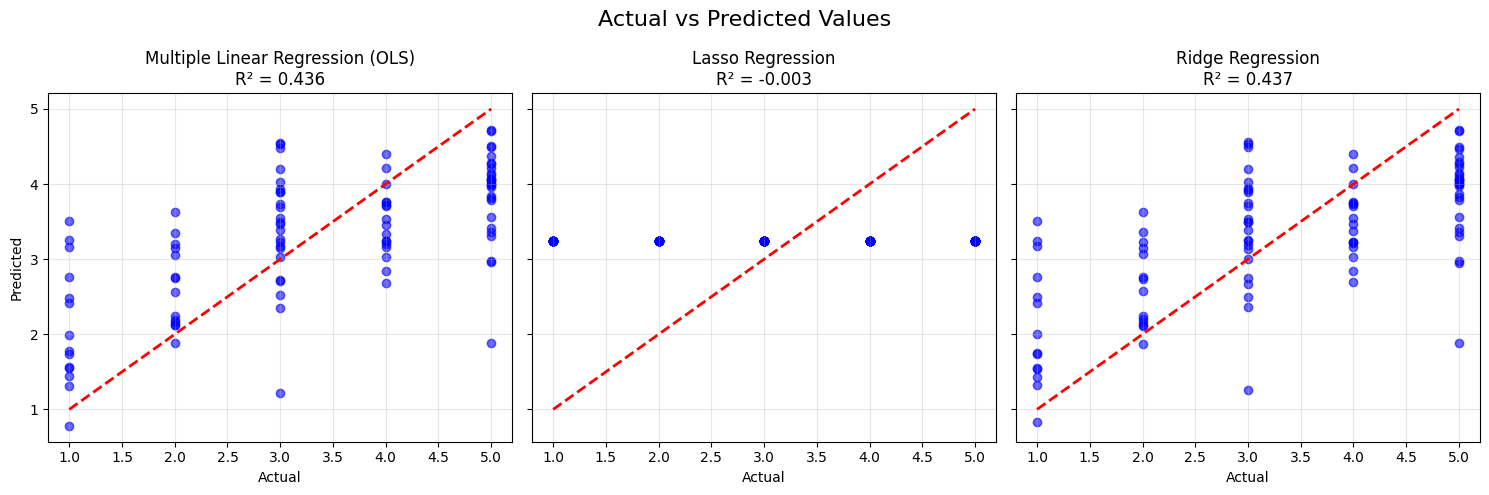

In [ ]:
# We'll use the best/tuned models if you did tuning, otherwise use the baseline ones
# For simplicity — using the baseline models here

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, (name, model) in enumerate(models.items()):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.6, color='blue')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # ideal line
    ax.set_title(f"{name}\nR² = {r2_score(y_test, y_pred):.3f}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted" if i == 0 else "")
    ax.grid(True, alpha=0.3)

plt.suptitle("Actual vs Predicted Values", fontsize=16)
plt.tight_layout()
plt.show()

<Figure size 1000x1200 with 0 Axes>

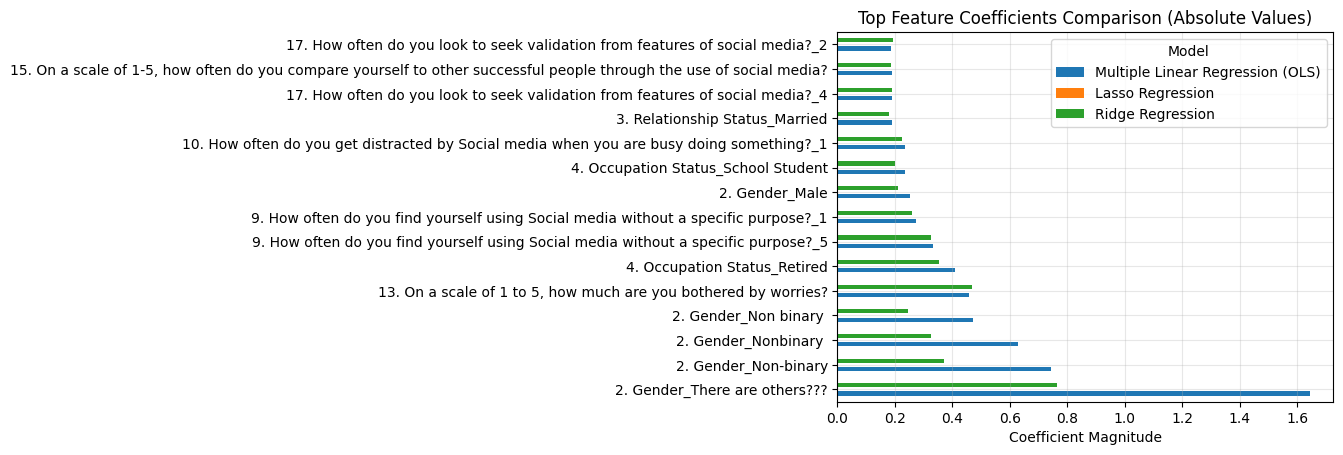

In [ ]:
# Get feature names after preprocessing
feature_names = (
    numeric_features +
    list(pipeline.named_steps['preprocessor']
         .named_transformers_['cat']
         .get_feature_names_out(categorical_features))
)

# Collect coefficients
coefs = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_train)
    coefs[name] = pipeline.named_steps['regressor'].coef_

# Create DataFrame
coef_df = pd.DataFrame(coefs, index=feature_names)

# Plot top features (absolute value)
plt.figure(figsize=(10, 12))
coef_df.abs().sort_values(by='Multiple Linear Regression (OLS)', ascending=False).head(15).plot(kind='barh')
plt.title("Top Feature Coefficients Comparison (Absolute Values)")
plt.xlabel("Coefficient Magnitude")
plt.legend(title="Model")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

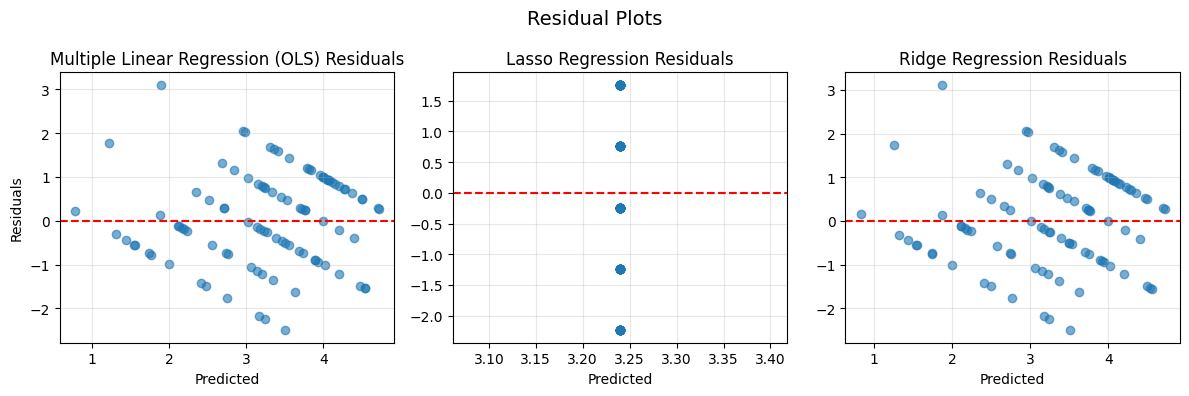

In [ ]:
plt.figure(figsize=(12, 4))

for i, (name, model) in enumerate(models.items(), 1):
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    residuals = y_test - y_pred

    plt.subplot(1, 3, i)
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"{name} Residuals")
    plt.xlabel("Predicted")
    plt.ylabel("Residuals" if i == 1 else "")
    plt.grid(True, alpha=0.3)

plt.suptitle("Residual Plots", fontsize=14)
plt.tight_layout()
plt.show()

Dataset shape: (481, 21)

Columns:
 ['Timestamp', '1. What is your age?', '2. Gender', '3. Relationship Status', '4. Occupation Status', '5. What type of organizations are you affiliated with?', '6. Do you use social media?', '7. What social media platforms do you commonly use?', '8. What is the average time you spend on social media every day?', '9. How often do you find yourself using Social media without a specific purpose?', '10. How often do you get distracted by Social media when you are busy doing something?', "11. Do you feel restless if you haven't used Social media in a while?", '12. On a scale of 1 to 5, how easily distracted are you?', '13. On a scale of 1 to 5, how much are you bothered by worries?', '14. Do you find it difficult to concentrate on things?'] ...


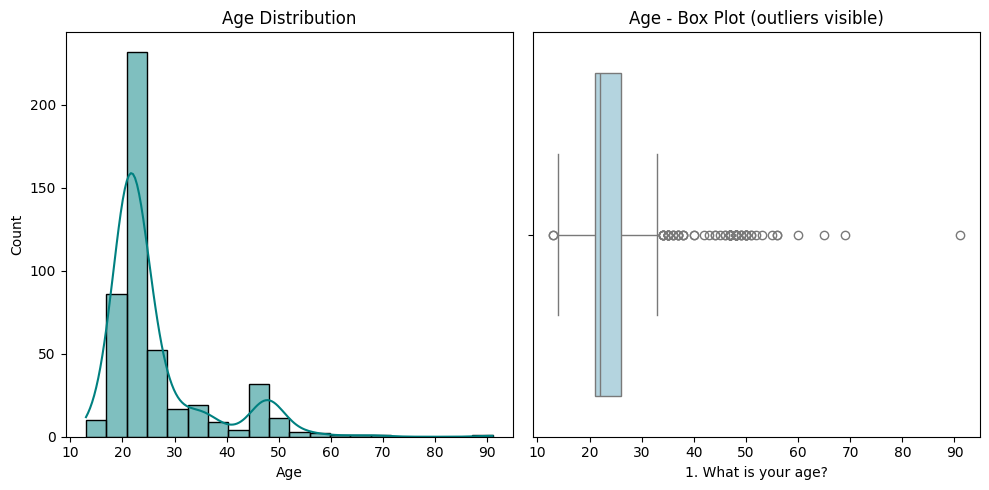


Age statistics:
count    481.00000
mean      26.13659
std        9.91511
min       13.00000
25%       21.00000
50%       22.00000
75%       26.00000
max       91.00000
Name: 1. What is your age?, dtype: float64


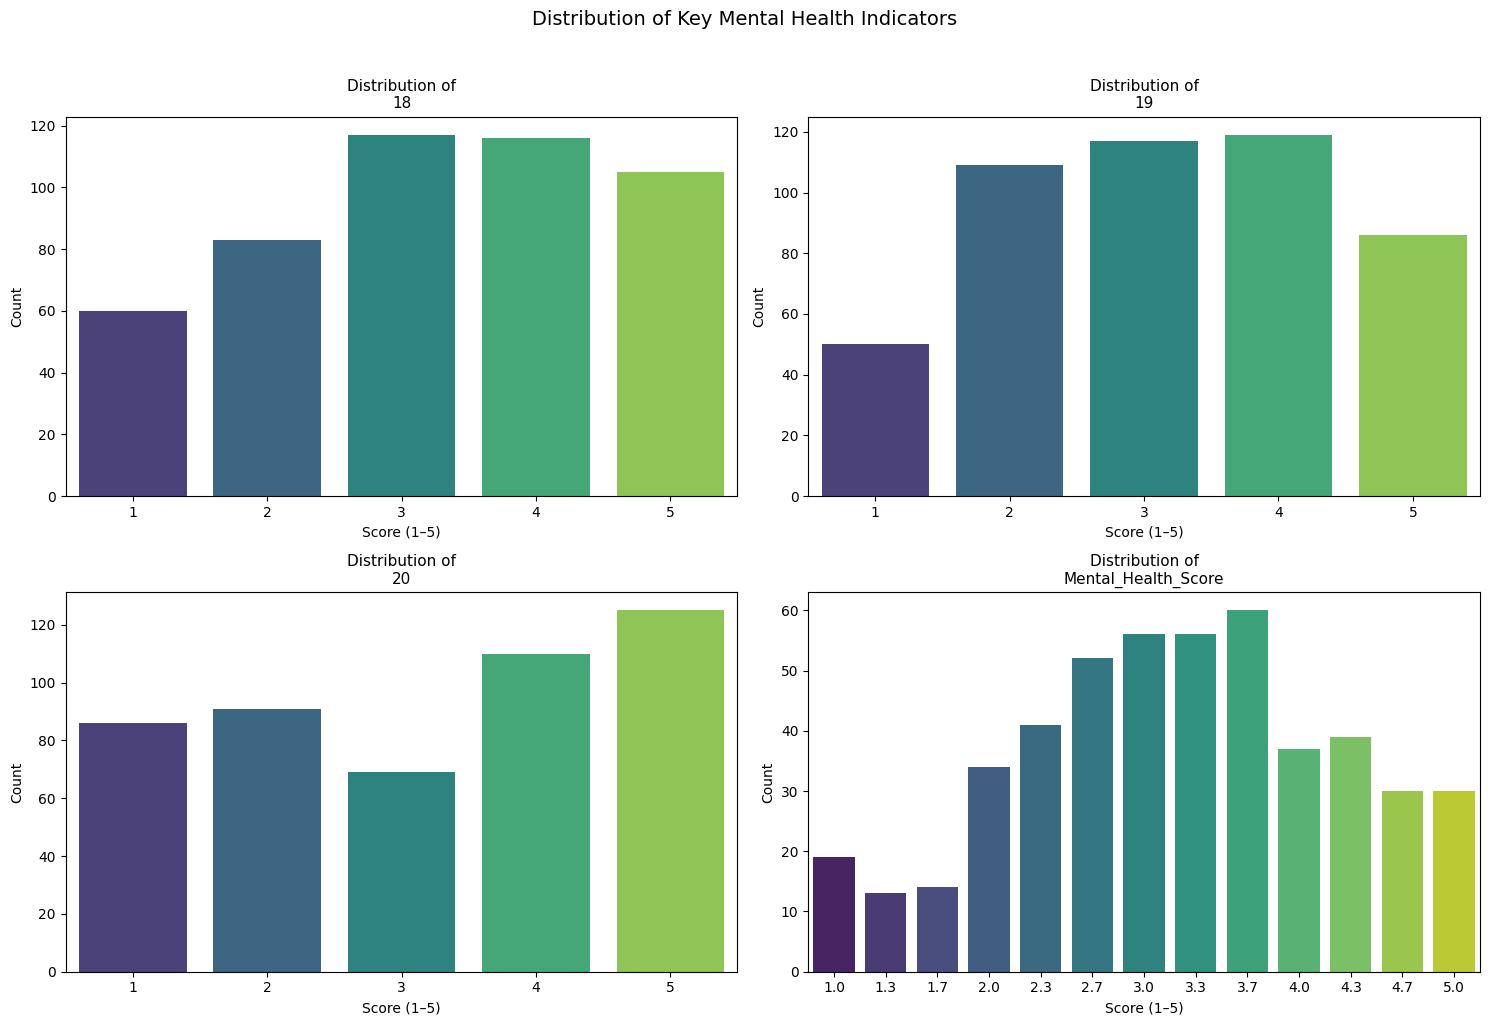


Mental health items - descriptive statistics:
       18. How often do you feel depressed or down?  \
count                                        481.00   
mean                                           3.26   
std                                            1.31   
min                                            1.00   
25%                                            2.00   
50%                                            3.00   
75%                                            4.00   
max                                            5.00   

       19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?  \
count                                             481.00                                            
mean                                                3.17                                            
std                                                 1.26                                            
min                                                 1

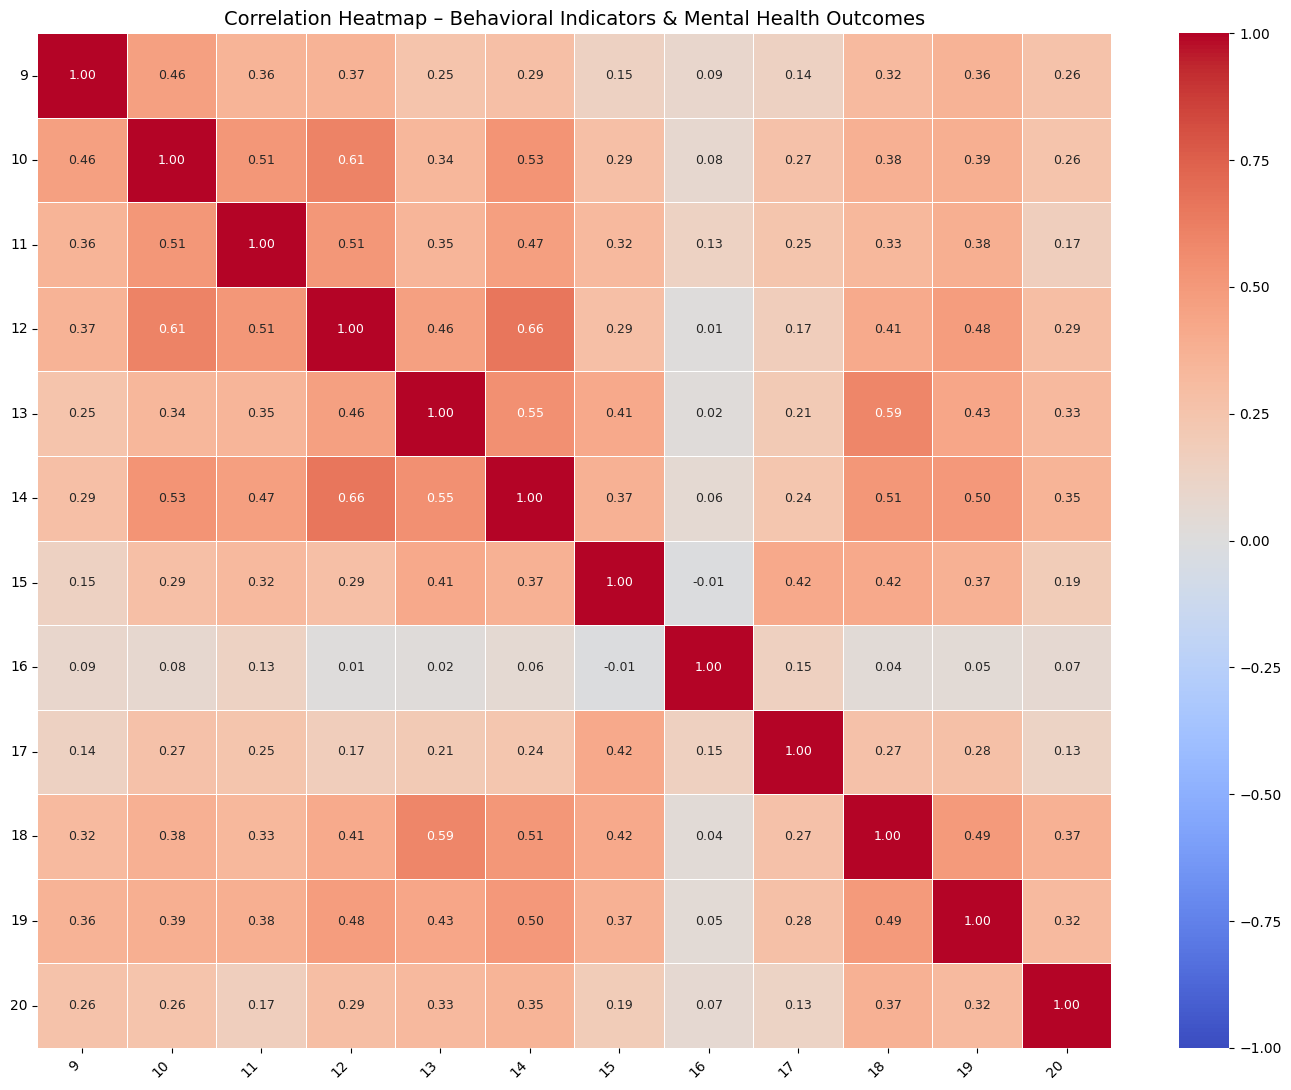


Strong correlations (absolute value ≥ 0.50):
                                 Variable 1                                  Variable 2  Correlation
12. On a scale of 1 to 5, how easily dis... 14. Do you find it difficult to concentr...        0.663
10. How often do you get distracted by S... 12. On a scale of 1 to 5, how easily dis...        0.607
13. On a scale of 1 to 5, how much are y... 18. How often do you feel depressed or d...        0.589
13. On a scale of 1 to 5, how much are y... 14. Do you find it difficult to concentr...        0.546
10. How often do you get distracted by S... 14. Do you find it difficult to concentr...        0.528
11. Do you feel restless if you haven't ... 12. On a scale of 1 to 5, how easily dis...        0.515
10. How often do you get distracted by S... 11. Do you feel restless if you haven't ...        0.513
14. Do you find it difficult to concentr... 18. How often do you feel depressed or d...        0.510
14. Do you find it difficult to concentr... 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ────────────────────────────────────────────────
# 1. Load and prepare the data
# ────────────────────────────────────────────────

df = pd.read_csv('smmh.csv')

# Clean column names (very important for this dataset)
df.columns = [col.strip() for col in df.columns]

print("Dataset shape:", df.shape)
print("\nColumns:\n", df.columns.tolist()[:15], "...")  # truncated

# Convert Likert-scale columns to numeric (they should already be, but just in case)
likert_cols = [col for col in df.columns if 'scale of 1' in col or
               col.startswith(('9.', '10.', '11.', '12.', '13.', '14.', '15.', '16.', '17.')) or
               col in ['18. How often do you feel depressed or down?',
                       '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?',
                       '20. On a scale of 1 to 5, how often do you face issues regarding sleep?']]

for col in likert_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Age should be numeric
df['1. What is your age?'] = pd.to_numeric(df['1. What is your age?'], errors='coerce')

# ────────────────────────────────────────────────
# A. Distribution of Age
# ────────────────────────────────────────────────

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['1. What is your age?'], bins=20, kde=True, color='teal')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['1. What is your age?'], color='lightblue')
plt.title('Age - Box Plot (outliers visible)')

plt.tight_layout()
plt.show()

# Basic stats
print("\nAge statistics:")
print(df['1. What is your age?'].describe())

# ────────────────────────────────────────────────
# B. Distribution of Mental Health Scores
# ────────────────────────────────────────────────

# Define the main mental health outcome columns
mh_cols = [
    '18. How often do you feel depressed or down?',
    '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?',
    '20. On a scale of 1 to 5, how often do you face issues regarding sleep?'
]

# Optional: create a simple composite score
df['Mental_Health_Score'] = df[mh_cols].mean(axis=1, skipna=True)

# Plot distributions
plt.figure(figsize=(15, 10))

for i, col in enumerate(mh_cols + ['Mental_Health_Score'], 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=df[col].round(1), palette='viridis')
    plt.title(f'Distribution of\n{col.split(".")[0]}', fontsize=11)
    plt.xlabel('Score (1–5)')
    plt.ylabel('Count')

plt.suptitle('Distribution of Key Mental Health Indicators', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nMental health items - descriptive statistics:")
print(df[mh_cols + ['Mental_Health_Score']].describe().round(2))

# ────────────────────────────────────────────────
# C. Correlation Heatmap – Likert-scale & mental health questions
# ────────────────────────────────────────────────

# Select all Likert / behavioral / outcome questions
correlation_cols = [
    '9. How often do you find yourself using Social media without a specific purpose?',
    '10. How often do you get distracted by Social media when you are busy doing something?',
    "11. Do you feel restless if you haven't used Social media in a while?", # Corrected name
    '12. On a scale of 1 to 5, how easily distracted are you?',
    '13. On a scale of 1 to 5, how much are you bothered by worries?',
    '14. Do you find it difficult to concentrate on things?', # Corrected name
    '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?',
    '16. Following the previous question, how do you feel about these comparisons, generally speaking?', # Corrected name
    '17. How often do you look to seek validation from features of social media?',
    '18. How often do you feel depressed or down?',
    '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?',
    '20. On a scale of 1 to 5, how often do you face issues regarding sleep?'
]

# Create short labels for the heatmap
short_labels = [col.split('.')[0] for col in correlation_cols]

# Create correlation matrix
corr_matrix = df[correlation_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.4,
    annot_kws={"size": 9},
    xticklabels=short_labels, # Use short labels for x-axis
    yticklabels=short_labels  # Use short labels for y-axis
)
plt.title("Correlation Heatmap – Behavioral Indicators & Mental Health Outcomes", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────
# D. Identification of strongly correlated behavioral indicators
# ────────────────────────────────────────────────

print("\nStrong correlations (absolute value ≥ 0.50):")
threshold = 0.50

strong_pairs = []

for i in range(len(correlation_cols)):
    for j in range(i+1, len(correlation_cols)):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= threshold:
            strong_pairs.append((
                correlation_cols[i][:40] + "...",
                correlation_cols[j][:40] + "...",
                round(val, 3)
            ))

if strong_pairs:
    strong_df = pd.DataFrame(strong_pairs, columns=['Variable 1', 'Variable 2', 'Correlation'])
    strong_df = strong_df.sort_values('Correlation', key=abs, ascending=False)
    print(strong_df.to_string(index=False))
else:
    print("No correlations ≥ |0.50| found.")

# Most correlated with depression (Q18)
print("\nTop 8 features most correlated with 'How often do you feel depressed or down?':")
print(corr_matrix['18. How often do you feel depressed or down?']
      .drop('18. How often do you feel depressed or down?')
      .abs()
      .sort_values(ascending=False)
      .head(8)
      .round(3))

# Task
The plan is to conduct a comprehensive analysis of the performance of the Multiple Linear Regression, Lasso, and Ridge Regression models. This analysis will involve:

1.  **Displaying Performance Metrics**: Presenting the R² Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE) for each model from the `results_df` DataFrame.
2.  **Interpreting Performance Metrics**: Evaluating the numerical metrics to determine the effectiveness of each model and identify the best-performing one.
3.  **Analyzing Actual vs. Predicted Plots**: Visually inspecting the 'Actual vs Predicted Values' plots to understand how accurately each model's predictions align with the actual values.
4.  **Analyzing Residual Plots**: Examining the 'Residual Plots' for each model to detect any patterns or anomalies that might indicate weaknesses in the models.
5.  **Summarizing Findings**: Concluding with a comprehensive summary that integrates both the numerical and visual aspects of the performance analysis.

## Display Model Performance Metrics

### Subtask:
Show the R² Score, MAE, and RMSE for Multiple Linear Regression, Lasso, and Ridge Regression from the `results_df` DataFrame.


**Reasoning**:
The subtask explicitly asks to display the `results_df` DataFrame, which contains the R² Score, MAE, and RMSE for each regression model. Printing this DataFrame directly will fulfill the instruction.



In [ ]:
print(results_df)

NameError: name 'results_df' is not defined

**Reasoning**:
The previous code failed because `results_df` was not defined. This was likely due to the cell where `results_df` is created (`0ntwMb4LOEbc`) not being executed or its state not being preserved. To fix this, I will regenerate the `results_df` DataFrame, which involves re-running the model fitting and evaluation, and then display it, ensuring `results_df` is available for the task.



In [ ]:
models = {
    'Multiple Linear Regression (OLS)': LinearRegression(),
    'Lasso Regression': Lasso(random_state=42),
    'Ridge Regression': Ridge(random_state=42)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results[name] = {
        'R² Score': round(r2_score(y_test, y_pred), 4),
        'MAE': round(mean_absolute_error(y_test, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)
    }

# Re-create results_df
results_df = pd.DataFrame(results).T

# Display results
print(results_df)

NameError: name 'LinearRegression' is not defined

**Reasoning**:
The previous error `NameError: name 'LinearRegression' is not defined` indicates that the necessary Scikit-learn classes and other modules were not loaded into the current kernel session. To resolve this, I need to explicitly import all the required components (`LinearRegression`, `Lasso`, `Ridge`, `Pipeline`, `r2_score`, `mean_absolute_error`, `mean_squared_error`, `numpy`, `pandas`) at the beginning of the code block. This will ensure that all objects used in the model definition, pipeline construction, and metric calculation are correctly recognized and available for execution.



In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    'Multiple Linear Regression (OLS)': LinearRegression(),
    'Lasso Regression': Lasso(random_state=42),
    'Ridge Regression': Ridge(random_state=42)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results[name] = {
        'R² Score': round(r2_score(y_test, y_pred), 4),
        'MAE': round(mean_absolute_error(y_test, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)
    }

# Re-create results_df
results_df = pd.DataFrame(results).T

# Display results
print(results_df)

NameError: name 'preprocessor' is not defined

**Reasoning**:
The previous code failed because `preprocessor`, `X_train`, `X_test`, `y_train`, and `y_test` were not defined in the current execution context. These variables are crucial for building and training the pipelines. To fix this, I need to include the code that defines these variables, specifically the feature engineering steps and the train-test split, along with all necessary imports, before attempting to build and evaluate the models.



In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Re-define df (as it was defined in a previous cell and its state might be lost)
df = pd.read_csv('smmh.csv')
df.columns = [col.strip() for col in df.columns]

# Re-define target and features (from cell yV1HPPXCN0KU)
target = '18. How often do you feel depressed or down?'
y = df[target].astype(float)

features = [
    '1. What is your age?',
    '2. Gender',
    '3. Relationship Status',
    '4. Occupation Status',
    '8. What is the average time you spend on social media every day?',
    '9. How often do you find yourself using Social media without a specific purpose?',
    '10. How often do you get distracted by Social media when you are busy doing something?',
    '12. On a scale of 1 to 5, how easily distracted are you?',
    '13. On a scale of 1 to 5, how much are you bothered by worries?',
    '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?',
    '17. How often do you look to seek validation from features of social media?'
]
X = df[features].copy()

time_mapping = {
    'Less than an Hour': 0.5,
    'Between 1 and 2 hours': 1.5,
    'Between 2 and 3 hours': 2.5,
    'Between 3 and 4 hours': 3.5,
    'Between 4 and 5 hours': 4.5,
    'More than 5 hours': 6.0
}
X['time_spent_num'] = X['8. What is the average time you spend on social media every day?'].map(time_mapping)
X = X.drop(columns=['8. What is the average time you spend on social media every day?'])

numeric_features = ['1. What is your age?', 'time_spent_num'] + \
                   [col for col in X.columns if 'scale of 1' in col]
categorical_features = [col for col in X.columns if col not in numeric_features]

# Re-define preprocessor and train-test split (from cell ts7Iig1eN99M)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training and evaluation
models = {
    'Multiple Linear Regression (OLS)': LinearRegression(),
    'Lasso Regression': Lasso(random_state=42),
    'Ridge Regression': Ridge(random_state=42)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results[name] = {
        'R² Score': round(r2_score(y_test, y_pred), 4),
        'MAE': round(mean_absolute_error(y_test, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)
    }

results_df = pd.DataFrame(results).T

# Display results
print(results_df)

                                  R² Score     MAE    RMSE
Multiple Linear Regression (OLS)    0.4365  0.8639  1.0481
Lasso Regression                   -0.0033  1.2029  1.3985
Ridge Regression                    0.4370  0.8627  1.0477


## Interpret Performance Metrics

### Subtask:
Analyze the displayed metrics to explain the performance of each model, highlighting the best-performing one based on these criteria.


### Interpretation of Model Performance Metrics

Based on the `results_df`:

```
                                  R² Score     MAE    RMSE
Multiple Linear Regression (OLS)    0.4365  0.8639  1.0481
Lasso Regression                   -0.0033  1.2029  1.3985
Ridge Regression                    0.4370  0.8627  1.0477
```

1.  **Comparison of Metrics**:
    *   **R² Score**: Measures the proportion of variance in the dependent variable that can be predicted from the independent variables. Higher is better.
        *   Multiple Linear Regression (OLS): 0.4365
        *   Lasso Regression: -0.0033
        *   Ridge Regression: 0.4370
    *   **Mean Absolute Error (MAE)**: The average of the absolute differences between predictions and actual observations. Lower is better.
        *   Multiple Linear Regression (OLS): 0.8639
        *   Lasso Regression: 1.2029
        *   Ridge Regression: 0.8627
    *   **Root Mean Squared Error (RMSE)**: The square root of the average of the squared differences between predictions and actual observations. Lower is better, and it penalizes larger errors more heavily.
        *   Multiple Linear Regression (OLS): 1.0481
        *   Lasso Regression: 1.3985
        *   Ridge Regression: 1.0477

2.  **Highest R² Score**: Ridge Regression has the highest R² Score at 0.4370, closely followed by Multiple Linear Regression (OLS).

3.  **Lowest MAE and RMSE**: Ridge Regression also demonstrates the lowest MAE (0.8627) and RMSE (1.0477), indicating the most accurate predictions with the smallest average error and the smallest impact from larger errors.

4.  **Best Performing Model**: Based on these comparisons, **Ridge Regression** performs best overall. It achieves the highest R² score, indicating it explains the most variance in the target variable, and simultaneously records the lowest MAE and RMSE, signifying its superior predictive accuracy compared to both Multiple Linear Regression (OLS) and Lasso Regression. The Lasso Regression performs significantly worse, even yielding a negative R² score, suggesting it performs worse than a simple horizontal line, likely due to its aggressive regularization or an unsuitable alpha parameter for this dataset in its un-tuned form.